## graph generation for perplexity vs. training iterations

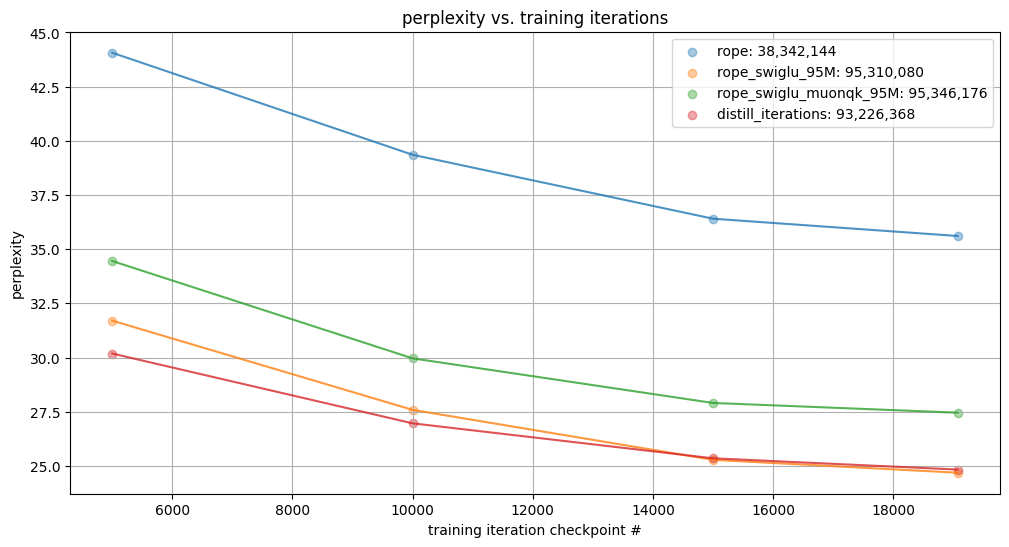

In [14]:
import re
import numpy as np
import matplotlib.pyplot as plt

FILES = ["rope", "rope_swiglu_95M", "rope_swiglu_muonqk_95M", "distill_iterations"]
PARAMS = ["38,342,144", "95,310,080", "95,346,176", "93,226,368"]

# plot
plt.figure(figsize=(12, 6))

for fp, param in zip(FILES, PARAMS):
    lines = []
    targets = [5000, 10000, 15000, 19072]
    with open(f"../results/{fp}_results.txt", 'r') as f:
        lines = f.readlines()

    found_xs, found_ys = [], []
    p = re.compile(r'Perplexity:\s*([+-]?\d*\.?\d+(?:[eE][+-]?\d+)?)')

    for i, line in enumerate(lines):
        for t in targets:
            if str(t) in line:
                m = p.search(line)
                if not m:
                    for j in range(i+1, min(i+6, len(lines))):
                        m = p.search(lines[j])
                        if m:
                            break
                if m:
                    found_xs.append(t)
                    found_ys.append(float(m.group(1)))
                targets = [x for x in targets if x != t]

    if found_xs:
        order = np.argsort(found_xs)
        x_vals = np.array(found_xs, dtype=int)[order]
        y_vals = np.array(found_ys, dtype=float)[order]
    else:
        x_vals = np.array([], dtype=int)
        y_vals = np.array([], dtype=float)

    if x_vals.size:
        plt.plot(x_vals, y_vals, '-', alpha=0.8)
        plt.scatter(x_vals, y_vals, alpha=0.4, label=f"{fp}: {param}")

plt.xlabel('training iteration checkpoint #')
plt.ylabel('perplexity')
plt.title(f'perplexity vs. training iterations')
plt.legend()
plt.grid(True)
plt.show()